# Week 7 — Heldout experiment

In [1]:
import json
import re
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone

import chromadb
import ollama
import numpy as np
import pandas as pd
import textstat
from sentence_transformers import SentenceTransformer
import matplotlib_inline
import matplotlib


/Users/charlesbruce/Desktop/UWE/venv-arm64/lib/python3.13/site-packages/textstat/textstat.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/charlesbruce/Desktop/UWE/venv-arm64/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
GENERATOR_MODEL = 'mistral:7b-instruct'
JUDGE_MODEL = 'llama3.1:8b'
TEMPERATURE = 0
SEED = 42

DB_DIR = 'chroma_db'
COLLECTION = 'medlineplus_english'
EMBED_MODEL = 'BAAI/bge-small-en-v1.5'
TOP_K = 5              # frozen - see header
MAX_PER_TOPIC = 2

LEVELS = ['standard', 'simplified']
SPLIT = 'heldout'          # switch to 'heldout' ONCE, at the very end
RUN_LOG =  f'wk7_readability_{SPLIT}.jsonl'

REFUSAL_MARKER = "i don't have reliable information"

RESUME = True          # skip questions already in the log, so a crash isn't fatal

In [3]:
# ---- everything below here is lifted from the v2 harness, unchanged, so results stay comparable
def generate(prompt, model=GENERATOR_MODEL):
    resp = ollama.chat(model=model, messages=[{'role': 'user', 'content': prompt}],
                       options={'temperature': TEMPERATURE, 'seed': SEED})
    return resp['message']['content'].strip()


embedder = SentenceTransformer(EMBED_MODEL)
coll = chromadb.PersistentClient(path=DB_DIR).get_collection(COLLECTION)


def retrieve(query, k=TOP_K, max_per_topic=MAX_PER_TOPIC):
    q_emb = embedder.encode('Represent this sentence for searching relevant passages: ' + query)
    res = coll.query(query_embeddings=[q_emb.tolist()], n_results=k * 10)
    hits, spill, per_topic = [], [], Counter()
    for doc, meta, dist in zip(res['documents'][0], res['metadatas'][0], res['distances'][0]):
        hit = {'text': doc, 'title': meta['title'], 'url': meta['url'],
               'group': meta['group'], 'similarity': round(1 - dist, 3)}
        if per_topic[meta['topic_id']] >= max_per_topic:
            spill.append(hit); continue
        per_topic[meta['topic_id']] += 1
        hits.append(hit)
        if len(hits) == k: break
    if len(hits) < k: hits.extend(spill[:k - len(hits)])
    return hits


RAG_PROMPT = """You are a patient education assistant. Answer the patient's question using ONLY the information in the passages below.

Rules:
- Use only facts stated in the passages. Do not add anything from your own knowledge.
- After each fact, cite the passage it came from by its topic title in square brackets, like [Heart Failure].
{reading_level}- If the passages do not contain the information needed to answer, say exactly: \"I don't have reliable information to answer that. Please ask your health care provider.\"
- Do not give a diagnosis. Do not recommend changing any medicine or dose.

Passages:
{passages}

Patient's question: {question}

Answer:"""

BASELINE_PROMPT = """You are a patient education assistant. Answer the patient's question.

Rules:
{reading_level}- Do not give a diagnosis. Do not recommend changing any medicine or dose.

Patient's question: {question}

Answer:"""

READING_LEVELS = {
    'standard': '- Write in plain, everyday language a patient can understand.\n',

    'simplified': ('- Write for a reading age of 9 to 11 years, as recommended by NHS '
                   'guidance for patient information. Use short sentences. Use everyday '
                   'words instead of medical terms where you can, and explain any medical '
                   'term you cannot avoid.\n'),
}

CITE_RE = re.compile(r'\[([^\]]+)\]')

def format_passages(hits):
    return '\n\n---\n\n'.join(f"Topic: {h['title']}\n{h['text']}" for h in hits)

def strip_citations(t):
    return re.sub(r'\s{2,}', ' ', CITE_RE.sub('', t)).strip()

def is_refusal(a):
    return REFUSAL_MARKER in a.lower()

def readability(a):
    c = strip_citations(a)
    if len(c.split()) < 10:
        return {'fkgl': None, 'fre': None, 'words': len(c.split())}
    return {'fkgl': round(textstat.flesch_kincaid_grade(c), 1),
            'fre': round(textstat.flesch_reading_ease(c), 1), 'words': len(c.split())}

def citation_scores(a, hits):
    cited = [c.strip() for c in CITE_RE.findall(a)]
    if not cited:
        return {'cited_any': False, 'citation_precision': None, 'n_citations': 0}
    retrieved = {h['title'].lower() for h in hits}
    return {'cited_any': True,
            'citation_precision': round(sum(1 for c in cited if c.lower() in retrieved) / len(cited), 2),
            'n_citations': len(cited)}

def split_sentences(t):
    return [p.strip() for p in re.split(r'(?<=[.!?])\s+', strip_citations(t)) if len(p.strip()) > 20]

FAITHFUL_PROMPT = """Here are passages from a medical reference, and one sentence from an answer that was written using them.

Passages:
{passages}

Sentence: \"{sentence}\"

Is the sentence supported by the passages? A sentence counts as supported if its factual claims appear in the passages, even if it is worded differently or uses simpler words. General advice to consult a doctor counts as supported.

Reply with exactly one word: YES or NO."""

RELEVANCY_PROMPT = """A patient asked: \"{question}\"

They received this answer:
\"{answer}\"

On a scale of 1 to 5, how well does the answer address the patient's actual question? 1 = not at all, 3 = partially, 5 = fully addresses it.

Reply with only the number."""

CONTEXT_PROMPT = """A patient asked: "{question}"

Here is one passage that was retrieved to help answer it:
\"\"\"{chunk}\"\"\"

Does this passage contain information that helps answer the patient's question? Answer YES if it is useful, NO if it is off-topic or unhelpful.

Reply with exactly one word: YES or NO."""

print('index loaded:', coll.count(), 'chunks')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7786.58it/s]


index loaded: 10337 chunks


## Retrieval scored once per question, not once per answer

The pilot recomputed hit rate, MRR and context precision for every answer. But retrieval doesn't
depend on the reading level or the arm - it's the same five passages every time. So it was doing
the same work six times per question, and context precision costs five judge calls each time.
Scoring it once per question and attaching the result to all six answers cuts roughly 2.5 hours
off the run and changes nothing about the numbers.

In [4]:
def score_retrieval_once(question, hits, gold_title):
    titles = [h['title'] for h in hits]
    if gold_title in titles:
        rank = titles.index(gold_title) + 1
        r = {'hit': 1, 'rank': rank, 'rr': round(1 / rank, 3)}
    else:
        r = {'hit': 0, 'rank': None, 'rr': 0.0}

    verdicts = [generate(CONTEXT_PROMPT.format(question=question, chunk=h['text']),
                         model=JUDGE_MODEL).strip().upper().startswith('YES') for h in hits]
    r['context_precision'] = round(sum(verdicts) / len(verdicts), 2) if verdicts else None
    r['useful_chunks'] = sum(verdicts)
    return r


def score_answer(record, arm):
    """metrics that DO depend on the answer - so these run per answer."""
    s = {'arm': arm, 'level': record['level']}
    s.update(readability(record['answer']))

    out = generate(RELEVANCY_PROMPT.format(question=record['question'],
                                           answer=strip_citations(record['answer'])),
                   model=JUDGE_MODEL)
    m = re.search(r'[1-5]', out)
    s['relevancy'] = int(m.group()) if m else None

    if is_refusal(record['answer']):
        s.update({'faithfulness': None, 'n_sentences': 0, 'unsupported': [], 'refused': True})
    else:
        sentences = split_sentences(record['answer'])
        if not sentences:
            s.update({'faithfulness': None, 'n_sentences': 0, 'unsupported': [], 'refused': False})
        else:
            passages = format_passages(record['hits'])
            verdicts, unsupported = [], []
            for sent in sentences:
                ok = generate(FAITHFUL_PROMPT.format(passages=passages, sentence=sent),
                              model=JUDGE_MODEL).strip().upper().startswith('YES')
                verdicts.append(ok)
                if not ok:
                    unsupported.append(sent)
            s.update({'faithfulness': round(sum(verdicts) / len(verdicts), 2),
                      'n_sentences': len(sentences), 'unsupported': unsupported, 'refused': False})

    if arm == 'rag':
        s.update(citation_scores(record['answer'], record['hits']))
    return s

## The run

Per question: retrieve once, score retrieval once, then generate RAG at three levels plus one
baseline. Four answers per question instead of six, and one retrieval scoring instead of six.

Writes to the log as it goes and skips anything already logged, so if it dies overnight I restart
and it picks up where it stopped.

In [5]:
questions = json.load(open(f'test_queries_{SPLIT}.json', encoding='utf-8'))
print(f'{SPLIT}: {len(questions)} questions')

done = set()
if RESUME:
    try:
        with open(RUN_LOG, encoding='utf-8') as f:
            done = {json.loads(line)['question'] for line in f}
        print(f'resuming - {len(done)} questions already logged')
    except FileNotFoundError:
        pass

todo = [q for q in questions if q['question'] not in done]
print(f'{len(todo)} to do -> {len(todo) * 3} answers')

heldout: 85 questions
85 to do -> 255 answers


In [6]:
t_start = time.time()

for i, q in enumerate(todo, 1):
    hits = retrieve(q['question'])
    retr = score_retrieval_once(q['question'], hits, q['topic_title'])   # once, reused below
    passages = format_passages(hits)

    rows = []
    for level in LEVELS:
        prompt = RAG_PROMPT.format(passages=passages, question=q['question'],
                                   reading_level=READING_LEVELS[level])
        rec = {'question': q['question'], 'answer': generate(prompt), 'hits': hits, 'level': level}
        rows.append(('rag', rec, score_answer(rec, 'rag')))

    # baseline at one level only - it's the retrieval control, not part of the readability test
    b_prompt = BASELINE_PROMPT.format(question=q['question'], reading_level=READING_LEVELS['standard'])
    b_rec = {'question': q['question'], 'answer': generate(b_prompt), 'hits': hits, 'level': 'standard'}
    rows.append(('baseline', b_rec, score_answer(b_rec, 'baseline')))

    with open(RUN_LOG, 'a', encoding='utf-8') as f:
        for arm, rec, sc in rows:
            f.write(json.dumps({
                'timestamp': datetime.now(timezone.utc).isoformat(),
                'question': q['question'], 'answer': rec['answer'],
                'retrieved': [{'title': h['title'], 'url': h['url'],
                               'similarity': h['similarity']} for h in hits],
                'scores': {**sc, **retr},
                'topic_title': q['topic_title'], 'group': q['group'], 'qtype': q['qtype'],
                'split': SPLIT,
                'config': {'generator': GENERATOR_MODEL, 'judge': JUDGE_MODEL,
                           'temperature': TEMPERATURE, 'seed': SEED, 'k': TOP_K,
                           'embed_model': EMBED_MODEL, 'level': rec['level']},
            }, ensure_ascii=False) + '\n')

    if i % 5 == 0 or i == len(todo):
        el = time.time() - t_start
        print(f'  {i}/{len(todo)} | {el/60:.0f} min | est. {el/i*(len(todo)-i)/60:.0f} min left')

print(f'\ndone in {(time.time() - t_start)/60:.0f} min')

  5/85 | 13 min | est. 210 min left
  10/85 | 27 min | est. 204 min left
  15/85 | 41 min | est. 191 min left
  20/85 | 56 min | est. 183 min left
  25/85 | 71 min | est. 171 min left
  30/85 | 86 min | est. 157 min left
  35/85 | 101 min | est. 145 min left
  40/85 | 117 min | est. 131 min left
  45/85 | 132 min | est. 118 min left
  50/85 | 150 min | est. 105 min left
  55/85 | 167 min | est. 91 min left
  60/85 | 181 min | est. 75 min left
  65/85 | 194 min | est. 60 min left
  70/85 | 210 min | est. 45 min left
  75/85 | 224 min | est. 30 min left
  80/85 | 237 min | est. 15 min left
  85/85 | 248 min | est. 0 min left

done in 248 min


## Question 1 — did the instruction actually work?

Before asking what simplification costs, check it happened. If grade6 doesn't read easier than
none, there's no trade-off to measure and the rest is meaningless.

In [7]:
runs = [json.loads(l) for l in open(RUN_LOG, encoding='utf-8')]
df = pd.DataFrame([{'question': r['question'], 'group': r['group'], 'qtype': r['qtype'],
                    **{k: v for k, v in r['scores'].items() if k != 'unsupported'}} for r in runs])
rag = df[df.arm == 'rag'].copy()
print(f'{len(df)} answers | {df.question.nunique()} questions')

print('\nreading level actually achieved (FKGL, lower = easier):')
print(rag.groupby('level')[['fkgl', 'fre', 'words']].agg(['mean', 'std']).round(1))

target = {'simplified': 6}
print('\ndid it hit the target?')
for lvl, t in target.items():
    sub = rag[(rag.level == lvl) & rag.fkgl.notna()]
    print(f'  {lvl}: mean FKGL {sub.fkgl.mean():.1f} vs target {t} '
          f'| within 1 grade: {(sub.fkgl.sub(t).abs() <= 1).mean():.0%} of answers')

255 answers | 85 questions

reading level actually achieved (FKGL, lower = easier):
            fkgl        fre       words      
            mean  std  mean   std  mean   std
level                                        
simplified   8.6  2.7  64.5  13.8  83.7  49.3
standard    10.2  2.9  56.5  13.6  92.0  50.7

did it hit the target?
  simplified: mean FKGL 8.6 vs target 6 | within 1 grade: 19% of answers


## Question 2 — what did it cost?

Paired: for each question, grade6 minus none. Comparing group means would let easy and hard
questions muddy the picture; pairing removes that because it's the same question both times.

Reporting a 95% confidence interval rather than a p-value. With 7 categories to look at, p-values
would invite reading noise as signal.

In [13]:
wide = rag.pivot_table(index='question', columns='level',
                       values=['fkgl', 'faithfulness', 'words', 'citation_precision'])
wide.columns = [f'{a}_{b}' for a, b in wide.columns]
wide = wide.join(rag.groupby('question')['group'].first())


def ci95(x):
    x = pd.Series(x).dropna()
    if len(x) < 2:
        return (np.nan, np.nan, np.nan, 0)
    m, se = x.mean(), x.std(ddof=1) / np.sqrt(len(x))
    return (m, m - 1.96 * se, m + 1.96 * se, len(x))


print('paired change vs the uncontrolled condition:\n')
for lvl in ['simplified']:
    for metric in ['fkgl', 'faithfulness']:
        a, b = f'{metric}_{lvl}', f'{metric}_standard'
        if a not in wide or b not in wide:
            continue
        m, lo, hi, n = ci95(wide[a] - wide[b])
        flag = '' if (lo < 0 < hi) else '   <-- CI excludes zero'
        print(f'  {lvl:7s} {metric:13s} {m:+.2f}  [95% CI {lo:+.2f}, {hi:+.2f}]  n={n}{flag}')
    print()

paired change vs the uncontrolled condition:

  simplified fkgl          -1.65  [95% CI -2.21, -1.09]  n=85   <-- CI excludes zero
  simplified faithfulness  -0.02  [95% CI -0.03, -0.00]  n=57   <-- CI excludes zero



In [14]:
# is the trade-off real at the level of individual questions? count which way each one moved
d = (wide['faithfulness_simplified'] - wide['faithfulness_standard']).dropna()
print(f'questions where simplified was LESS faithful: {(d < 0).sum()}')
print(f'                          no change     : {(d == 0).sum()}')
print(f'                          MORE faithful : {(d > 0).sum()}')
print(f'\nbiggest drops:')
for q, v in d.nsmallest(5).items():
    print(f'  {v:+.2f}  {q[:70]}')

questions where simplified was LESS faithful: 4
                          no change     : 53
                          MORE faithful : 0

biggest drops:
  -0.33  What is (are) Ischemic Stroke?
  -0.25  What are the symptoms of Paget's Disease of Bone?
  -0.20  Do you have information about Vasectomy
  -0.17  What are the treatments for Aphasia?
  +0.00  Do you have information about A1C


## Question 3 — does the cost differ by medical category?

The novel bit. Only the pre-registered analysis categories get individual claims - the tier list
was fixed before any of this ran, so I can't pick favourable ones after the fact.

Reading this honestly: 7 categories means 7 comparisons, so by chance alone one could look
"significant". These are exploratory, and with 7-11 questions each the intervals will be wide.

In [10]:
cats = json.load(open('analysis_categories.json', encoding='utf-8'))['analysis_categories']
wide['delta_faith'] = wide['faithfulness_simplified'] - wide['faithfulness_standard']
wide['delta_fkgl']  = wide['fkgl_simplified'] - wide['fkgl_standard']

print('faithfulness change from simplifying, by category:\n')
rows = []
for g in cats:
    sub = wide[wide.group == g]
    m, lo, hi, n = ci95(sub['delta_faith'])
    fk, *_ = ci95(sub['delta_fkgl'])
    rows.append({'category': g, 'n': n, 'faith_change': round(m, 3),
                 'ci_low': round(lo, 3), 'ci_high': round(hi, 3), 'fkgl_change': round(fk, 2)})
cat_df = pd.DataFrame(rows).sort_values('faith_change')
print(cat_df.to_string(index=False))

print('\naggregate-only categories pooled (no individual claims):')
pooled = wide[~wide.group.isin(cats)]
m, lo, hi, n = ci95(pooled['delta_faith'])
print(f'  {m:+.3f}  [95% CI {lo:+.3f}, {hi:+.3f}]  n={n}')

cat_df.to_csv(f'wk6_category_results_{SPLIT}.csv', index=False)

faithfulness change from simplifying, by category:

                    category  n  faith_change  ci_low  ci_high  fkgl_change
   Bones, Joints and Muscles  3        -0.083  -0.247    0.080        -1.70
            Brain and Nerves  3        -0.057  -0.168    0.054        -1.38
Blood, Heart and Circulation  6        -0.055  -0.163    0.053        -1.71
                     Cancers  5         0.000   0.000    0.000        -2.74
            Digestive System  4         0.000   0.000    0.000        -2.80
                  Infections  7         0.000   0.000    0.000        -1.20
  Mental Health and Behavior  4         0.000   0.000    0.000        -0.50

aggregate-only categories pooled (no individual claims):


  -0.008  [95% CI -0.024, +0.008]  n=25


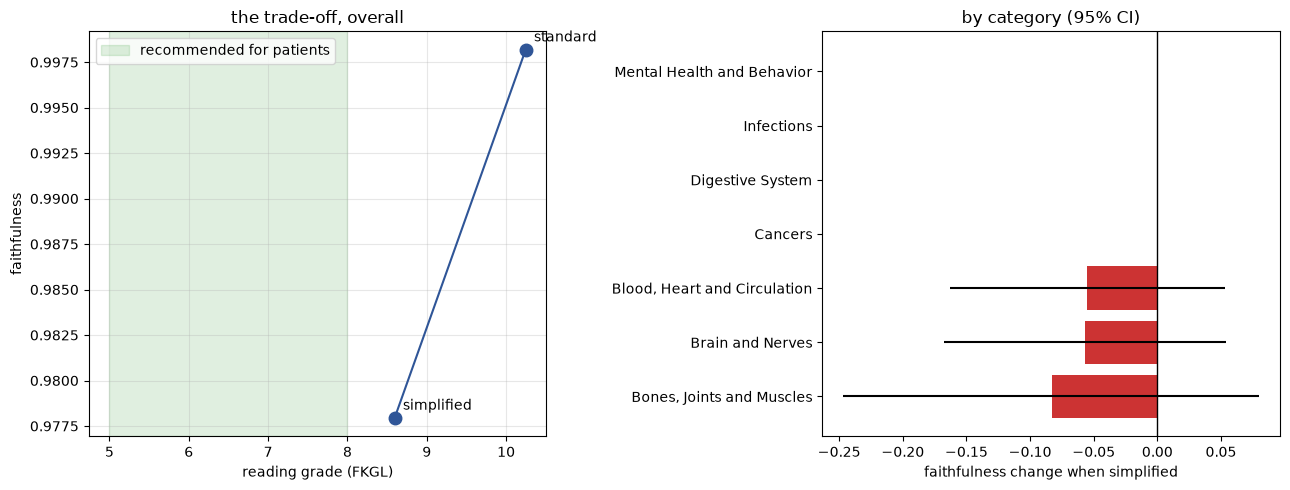

In [11]:
# the headline plot: readability against faithfulness, one line per category
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

means = rag.groupby('level')[['fkgl', 'faithfulness']].mean().reindex(LEVELS)
axes[0].plot(means.fkgl, means.faithfulness, 'o-', color='#2f5597', markersize=9)
for lvl, r in means.iterrows():
    axes[0].annotate(lvl, (r.fkgl, r.faithfulness), textcoords='offset points', xytext=(6, 6))
axes[0].axvspan(5, 8, alpha=0.12, color='green', label='recommended for patients')
axes[0].set_xlabel('reading grade (FKGL)'); axes[0].set_ylabel('faithfulness')
axes[0].set_title('the trade-off, overall'); axes[0].legend(); axes[0].grid(alpha=0.3)

cd = cat_df.dropna(subset=['faith_change'])
axes[1].barh(cd.category, cd.faith_change,
             xerr=[cd.faith_change - cd.ci_low, cd.ci_high - cd.faith_change],
             color=['#c00000' if v < 0 else '#2f5597' for v in cd.faith_change], alpha=0.8)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('faithfulness change when simplified')
axes[1].set_title('by category (95% CI)')
plt.tight_layout()
plt.savefig(f'wk6_tradeoff_{SPLIT}.png', dpi=150)
plt.show()

In [12]:
flagged = [(r['question'], s) for r in runs
           if r['scores'].get('level') == 'simplified' and r['scores'].get('arm') == 'rag'
           for s in r['scores'].get('unsupported', [])]

print(f'{len(flagged)} sentences judged unsupported at simplified\n')
for q, s in flagged[:15]:
    print(f'  Q: {q[:58]}')
    print(f'     {s[:105]}\n')

8 sentences judged unsupported at simplified

  Q: What is (are) Ischemic Stroke?
     It's a type of stroke that lasts longer than a few minutes and can cause lasting brain damage, long-term 

  Q: What are the treatments for Aphasia?
     Mental health counseling can help people with aphasia and their families manage difficult emotions and pl

  Q: Do you have information about Vasectomy
     The surgery cuts the tubes called vas deferens, which carry sperm out of the testicles.

  Q: What are the symptoms of Paget's Disease of Bone?
     The symptoms of Paget's Disease of Bone can include pain, swelling, and warmth in the affected area .

  Q: How to prevent Urinary Tract Infections?
     Drink plenty of water to help flush bacteria out of your urinary system.

  Q: How to prevent Urinary Tract Infections?
     Empty your bladder fully when you urinate, especially after sexual activity.

  Q: How to prevent Urinary Tract Infections?
     If you have diabetes, well-controlled blood s

In [15]:
h = pd.DataFrame([{'question': r['question'], **{k:v for k,v in r['scores'].items() if k!='unsupported'}}
                  for r in runs])
comp = pd.concat([h[(h.arm=='rag') & (h.level=='standard')].assign(a='RAG'),
                  h[h.arm=='baseline'].assign(a='no-RAG')]).groupby('a').agg(
    faithfulness=('faithfulness','mean'), scored=('faithfulness','count'),
    citation_precision=('citation_precision','mean'), relevancy=('relevancy','mean'),
    fkgl=('fkgl','mean'), words=('words','mean'), refused=('refused','sum')).round(3)
print(comp)
print('\nlowest faithfulness, baseline:')
print(h[h.arm=='baseline'].nsmallest(5,'faithfulness')[['question','faithfulness','words']].to_string(index=False))

        faithfulness  scored  citation_precision  relevancy    fkgl    words  \
a                                                                              
RAG            0.998      66               0.938      3.882  10.246   92.024   
no-RAG         0.831      85                 NaN      4.388   9.939  182.800   

        refused  
a                
RAG          19  
no-RAG        0  

lowest faithfulness, baseline:
                                                                question  faithfulness  words
                              What are the stages of Gallbladder Cancer?          0.22    165
what research (or clinical trials) is being done for Cephalic Disorders?          0.27    201
                                 Do you have information about Volcanoes          0.31    475
                                      What to do for Ulcerative Colitis?          0.47    264
     what research (or clinical trials) is being done for Rett Syndrome?          0.50    208
